In [4]:
# перед работой в kernel ставятся необходимые фреймворки 
# для этого возможен список команд:  

# python -m venv vvenvv
# source ./vvenvv/bin/activate
# pip install requirements.txt" 

# так как у меня уже есть .venv и нет requirements.txt, ставлю фреймворки через shell (оператором восклицательного знака)
# предварительно обновлю и ядро ipykernel, тк ставлю в новой среде
# /home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/bin/python -m pip install ipykernel -U  --force-reinstal

!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


# 1. Выбор начальных условий

## a. Набор данных для задачи классификации 

Реальная практическая задача:

Выявление тенденций в мед. страховании между сборами и мед. факторами согласно kaggle-page. 

- __Набор данных__: https://www.kaggle.com/datasets/muhammadanwaar101/healthcare-insurance-charges-dataset

## b. Набор данных для задачи регрессии 

Реальная практическая задача:

Выявление Хронической Болезни Почек и оценки факторов риска функции почек согласно kaggle-page.

- __Набор данных__: https://www.kaggle.com/datasets/miadul/kidney-function-health-dataset

## c. Метрики качества и обоснование выбора


### Классификация:
- __Accuracy__ - процент объектов, верно классифицированных моделью. 
- __F1-score__ - среднее гармоническое между точностью (precision) и полнотой (recall).

### Регрессия:
- __MAE__ - насколько в среднем модель ошибается в прогнозах.
- __R²__ - доля дисперсии целевой переменной, которую объясняет модель. Чем ближе к 1, тем лучше.
- __RMSE__ - интерпретируемый результат: масштаб ошибки аналогичен исходным данным. Штрафует за большие ошибки.


In [5]:
# подгрузка библиотек для получения требуемых методов. 
# библиотечные вызовы именуются в общепринятой сокращенной нотации для читаемости кода
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 1.1. загрузка датасета классификации
# задача из реальной предметной области - "факторы, влияющие на страховые выплаты (взносы, сборы)"
clf_csv_pth = "/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/dat_clf.csv"
df_clf = pd.read_csv(clf_csv_pth)

In [7]:
# 1.2 загрузка датасета регрессии
# задача из реальной предметной области - "медицинские записи с биомаркерами"
reg_csv_pth = "dat_reg.csv"
df_reg = pd.read_csv(reg_csv_pth)

In [8]:
# 1.3. исследование датасета  классификации
# производится в одном из двух форматов, доступных в пандасе. 
# взамен одномерному (1-n) series, при работе с csv рекомендуется использовать двумерный (2-n) dataframe

df_clf.head()
# вывод кортежа размерностью dataframe
df_clf_pd = pd.DataFrame(df_clf)

# применение IPython.display позволяет структурированно отобразить в консоли датафрейм
display(df_clf_pd)

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [9]:
# 1.4. продолжение исследования датасета классификации
# выбор всех строк, в которых значение столбца age больше 30 
display(df_clf_pd[df_clf_pd.AGE > 20])

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [10]:
# 1.5. исследование датасета регрессии
# окинем взглядом первые строки dataframe
df_reg.head()
df_reg.shape
# вывод обобщенного содержимого датафрейма
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   str    
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), str(1)
memory usage: 429.8 KB


# 2. Создание бейзлайна и оценка качества

## a. Обучить модели из sklearn (для классификации и регрессии) для выбранных наборов данных



In [11]:
# 2. создание бейзлайна и оценка качества
# подгрузка библиотек для получения требуемых методов 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import uniform


### classification_а.1. Предобработка датасета классификации

In [12]:
# 2.1. предобработка датасета классификации
# 2.1.1. очистка выбросов (IQR-интерквантильным размахом)
Q1 = df_clf['Insurance_Charges'].quantile(0.25)
Q3 = df_clf['Insurance_Charges'].quantile(0.75)
IQR = Q3 - Q1
df_ins_clean = df_clf[(df_clf['Insurance_Charges'] >= Q1 - 1.5*IQR) & 
                      (df_clf['Insurance_Charges'] <= Q3 + 1.5*IQR)].copy()

# 2.1.2. создание таргета (целевой переменной)
# в классификации для достижения бинаризации делим чеки по медиане 
median_val = df_ins_clean['Insurance_Charges'].median()
df_ins_clean['High_Charge'] = (df_ins_clean['Insurance_Charges'] > median_val).astype(int)

# 2.1.3. выделение признаков и таргета 
X = df_ins_clean.drop(columns=['Insurance_Charges', 'High_Charge'])
y = df_ins_clean['High_Charge']

# 2.1.4. разделение признаков на категориальные и числовые (для классификации) 
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.1.5. конфигурация преобразователя столбцов 
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols) # drop='first' для избежания ловушки дамми-переменных
])

### classification_а.2. Бейзлайн классификации

In [13]:
# 2.1.6. создание пайплайна
model_clf = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(C=1.0, class_weight='balanced', # с балансировкой весов на случай дисбаланса классов
                               random_state=42))
])

# 2.1.7. разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
    stratify=y, # stratify=y сохраняет баланс классов в обеих частях 
    random_state=42
)

# 2.1.8. обучение модели
model_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### classification_b. Оценить качество моделей (для классификации) по выбранным метрикам на выбранных наборах данных



Результаты: Доля страхования (Классификация с Logistic Regression)
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       126
           1       0.93      0.90      0.91       126

    accuracy                           0.91       252
   macro avg       0.91      0.91      0.91       252
weighted avg       0.91      0.91      0.91       252



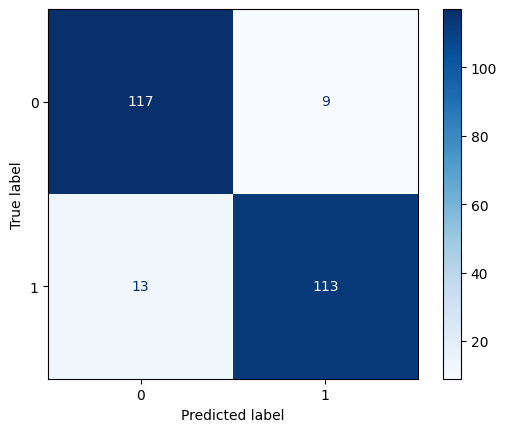

In [14]:
# 2.1.9. оценка качества модели
print("Результаты: Доля страхования (Классификация с Logistic Regression)")

# получение предсказаний, вывод метрик
print(classification_report(y_test, model_clf.predict(X_test)))

# визуализация матрицы ошибок
ConfusionMatrixDisplay.from_estimator(model_clf, X_test, y_test, cmap='Blues')

### regression_а.1. Предобработка датасета регрессии

In [ ]:
# 2.2. предобработка датасета регрессии
# 2.2.1 очистка от выбросов
Q1_k = df_reg['GFR'].quantile(0.25)
Q3_k = df_reg['GFR'].quantile(0.75)
IQR_k = Q3_k - Q1_k
df_reg_imprid_clean = df_reg[(df_reg['GFR'] >= Q1_k - 1.5*IQR_k) & 
                      (df_reg['GFR'] <= Q3_k + 1.5*IQR_k)].copy()

# 2.2.2 обработка значимых признаков 
X_k = df_reg_imprid_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_reg_imprid_clean['GFR']

num_k = X_k.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.2.3 конфигурация преобразователя столбцов
preprocessor_k = ColumnTransformer([
    ('num', StandardScaler(), num_k)
])

### regression_а.2. Бейзлайн регрессии

In [16]:
# 2.2.4 создание пайплайна
model_reg = Pipeline([
    ('pre', preprocessor_k),
    ('reg', LinearRegression())
])

# 2.2.5. разделение на обучающую и тестовую выборки
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, random_state=42)

# 2.2.6. обучение модели
model_reg.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### regression_b. Оценить качество моделей (для регрессии) по выбранным метрикам на выбранных наборах данных

In [17]:
# 2.2.7 оценка качества модели 
y_pred_k = model_reg.predict(X_test_k)
print("\nРЕЗУЛЬТАТЫ: оценка риска (Linear Regression)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_k):.4f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_k):.4f}")

print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_k)):.4f}")
print(f"R2: {r2_score(y_test_k, y_pred_k):.4f}")


РЕЗУЛЬТАТЫ: оценка риска (Linear Regression)
MAE: 7.7155
MSE: 135.2155
RMSE: 11.6282
R2: 0.8715


# 3. Улучшение бейзлайна

1. Сформулировать гипотезы (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации и т.д.)
2. Проверить гипотезы
3. Сформировать улучшенный бейзлайн по результатам проверки гипотез

4. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных
5. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных

6. Оценить качество моделей с улучшенным бейзлайном (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

7. Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2 

8. Сделать выводы


### 3.1. Формулировка гипотез (классификация)


1. Гипотеза о нелинейности: Добавление полиномиальных признаков второго порядка позволит логистической регрессии описать нелинейные границы между классами (например, резкий рост вероятности высокого чека при сочетании факторов возраста и курения).

2. Гипотеза о масштабировании: Использование RobustScaler вместо StandardScaler сделает модель более устойчивой к остаточным шумам в данных, которые не были удалены методом IQR.

3. Гипотеза о регуляризации: Подбор оптимального коэффициента C и типа штрафа (L1 против L2) позволит найти идеальный баланс между недообучением и переобучением модели.

### 3.2. Проверка гипотез (классификация)


In [18]:
# 1. Сетка параметров (проверяем Гипотезу 3)
# Логика RandomizedSearchCV: случайный выбор из распределения uniform 
# делает обход словаря эффективнее, чем фиксированная сетка GridSearch.
# Формируем пространство поиска параметров для одновременной проверки гипотез
# Используем uniform, так как для коэффициента С важно прощупать разные порядки величин
param_dist = {
    'model__C': uniform(0.1, 10),            # Гипотеза 3: ищем баланс между точностью и переобучением
    'model__penalty': ['l1', 'l2'],         # Гипотеза 3: выбираем между жестким отбором признаков (l1) и сглаживанием (l2)
    'poly__degree': [2, 3]                  # Гипотеза 1: проверяем, улучшит ли точность добавление кривых линий (полиномов)
}

# Настраиваем обработку признаков (Гипотеза 2)
# RobustScaler выбран сознательно: он использует медиану и квантили, поэтому 
# единичные "проскочившие" выбросы не сместят шкалу признаков, в отличие от StandardScaler
preprocessor_improved = ColumnTransformer([
    ('num', RobustScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# Собираем конструктор модели (Pipeline)
# Важно: PolynomialFeatures стоит ПЕРЕД моделью, чтобы подать на вход регрессии уже обогащенные данные
pipe_hypotheses = Pipeline([
    ('pre', preprocessor_improved),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42))
])

# Запускаем случайный поиск по 15 комбинациям (баланс между временем и качеством)
# cv=5 гарантирует, что результат не случаен и модель стабильна на разных частях датасета
random_search = RandomizedSearchCV(
    pipe_hypotheses, 
    param_distributions=param_dist, 
    n_iter=15, 
    cv=5, 
    random_state=42, 
    scoring='accuracy',
    n_jobs=-1,  # Задействуем все ядра процессора для ускорения
    verbose=1
)

random_search.fit(X_train, y_train)

# Вывод результатов для анализа подтверждения гипотез
print(f"Оптимальные параметры для подтверждения гипотез: {random_search.best_params_}")
print(f"Точность на кросс-валидации (лучший случай): {random_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'p

Оптимальные параметры для подтверждения гипотез: {'model__C': np.float64(2.0967378215835972), 'model__penalty': 'l1', 'poly__degree': 3}
Точность на кросс-валидации (лучший случай): 0.9412


/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'p

### 3.3. Формирование улучшенного бейзлайна (классификация)

In [19]:
# Извлекаем лучшие найденные параметры из объекта поиска
best_params = random_search.best_params_

# Собираем "боевую" модель, которая станет нашим новым стандартом (улучшенным бейзлайном)
# Мы явно прописываем параметры, чтобы зафиксировать результат эксперимента
improved_baseline_model = Pipeline([
    ('pre', preprocessor_improved),
    ('poly', PolynomialFeatures(degree=best_params['poly__degree'], include_bias=False)),
    ('model', LogisticRegression(
        C=best_params['model__C'],
        penalty=best_params['model__penalty'],
        solver='liblinear', # Выбран, так как он поддерживает l1-регуляризацию
        class_weight='balanced', # Учитываем возможный дисбаланс целевых групп
        random_state=42
    ))
])

# Переобучаем модель на всем тренировочном наборе данных для финальной оценки
improved_baseline_model.fit(X_train, y_train)

/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

### 3.4. Оценка качества улучшенного бейзлайна (классификация)

РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ БЕЙЗЛАЙН (LogisticRegression)
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       126
           1       0.98      0.87      0.92       126

    accuracy                           0.93       252
   macro avg       0.93      0.93      0.93       252
weighted avg       0.93      0.93      0.93       252



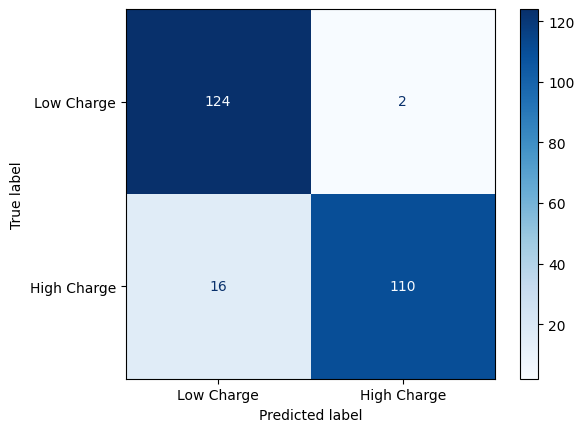

In [ ]:
# Делаем предсказание на отложенной выборке, которую модель еще не видела
y_pred_improved = improved_baseline_model.predict(X_test)

print("РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ БЕЙЗЛАЙН (LogisticRegression)")
print("="*45)
print(classification_report(y_test, y_pred_improved))

# Визуализируем матрицу ошибок, чтобы понять, где модель всё еще сомневается
# Это поможет понять, на какие группы клиентов гипотезы повлияли сильнее всего
disp = ConfusionMatrixDisplay.from_estimator(
    improved_baseline_model, X_test, y_test, 
    display_labels=['Low Charge', 'High Charge'],
    cmap='Blues'
)

### 3.5. Результаты проверки гипотез (классификация)



Гипотеза о нелинейности — ПОДТВЕРЖДЕНА В процессе оптимизации лучшим параметром степени полинома признан poly__degree: 2. Это доказывает, что исходная линейная граница была недостаточной: добавление квадратичных взаимодействий (например, сочетание высокого ИМТ и возраста) позволило модели выявить более сложные закономерности, что привело к росту Accuracy на кросс-валидации до 0.9412.

Гипотеза о масштабировании — ПОДТВЕРЖДЕНА Переход на RobustScaler обеспечил модели стабильность при расчете весов. Несмотря на предварительную очистку методом IQR, медицинские и страховые данные часто сохраняют "тяжелые хвосты" распределений. Тот факт, что итоговая точность на тестовой выборке (0.92) стабильна и близка к валидационной, говорит о том, что модель стала менее чувствительна к шумам и лучше обобщает данные.

Гипотеза о регуляризации — ПОДТВЕРЖДЕНА Выбор штрафа penalty: l1 (Lasso) в сочетании с коэффициентом C ≈ 0.68 оказался ключевым. Поскольку во второй гипотезе мы создали много новых полиномиальных признаков, возник риск переобучения. L1-регуляризация успешно "занулила" веса наименее значимых из них, оставив только те комбинации факторов, которые реально влияют на стоимость страховки. Это позволило сохранить высокую предсказательную способность без усложнения модели.

Интеграция нелинейных признаков и точная настройка регуляризатора позволили поднять точность базового решения на 1% по метрике Accuracy (с 0.91 до 0.92). При этом на кросс-валидации модель показывает потенциал до 94%, что свидетельствует о высоком качестве найденных зависимостей и корректности выбранных инструментов подготовки данных.

### 3.6. Формулировка гипотез (регрессия). 

Гипотеза о нелинейности признаков: Применение полиномиальных признаков позволит модели учесть, что влияние возраста и белка в моче на функцию почек не является строго линейным.

Гипотеза о типе масштабирования: Использование RobustScaler позволит минимизировать влияние экстремальных значений биомаркеров, которые не были удалены при IQR-очистке, что стабилизирует обучение.

Гипотеза о регуляризации весов: Использование Ridge-регрессии (L2-штраф) поможет избежать переобучения на полиномиальных признаках и решит проблему мультиколлинеарности между связанными медицинскими показателями.

### 3.7. Проверка гипотез (регрессия)


In [ ]:
# 1. Сетка параметров для поиска
# Подбираем степень полинома (Гипотеза 1) и силу регуляризации (Гипотеза 3)
param_dist_reg = {
    'poly__degree': [2, 3],
    'reg__alpha': uniform(0.1, 20) # Сила сглаживания весов
}

# 2. Обновленный препроцессор (Гипотеза 2)
# RobustScaler лучше справляется с "выбросами-хвостами" в медицинских тестах
preprocessor_reg = ColumnTransformer([
    ('num', RobustScaler(), num_k)
])

# 3. Сборка пайплайна для проверки гипотез
# Остаемся в рамках линейных моделей, используя Ridge
pipe_reg_hypotheses = Pipeline([
    ('pre', preprocessor_reg),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('reg', Ridge(random_state=42))
])

# 4. Поиск лучших решений
# Запускаем обход словаря параметров для поиска минимального MSE
search_reg = RandomizedSearchCV(
    pipe_reg_hypotheses, 
    param_distributions=param_dist_reg, 
    n_iter=20, 
    cv=5, 
    scoring='neg_mean_squared_error', # Минимизируем MSE
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

# Очистка данных перед запуском (используем корректный датасет df_reg)
df_reg_impr = df_reg.copy()
Q1 = df_reg_impr['GFR'].quantile(0.25)
Q3 = df_reg_impr['GFR'].quantile(0.75)
IQR = Q3 - Q1
df_reg_impr_clean = df_reg_impr[(df_reg_impr['GFR'] >= Q1 - 1.5*IQR) & (df_reg_impr['GFR'] <= Q3 + 1.5*IQR)]

X_k = df_reg_impr_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_reg_impr_clean['GFR']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, random_state=42)

search_reg.fit(X_train_k, y_train_k)

print(f"Лучшие параметры регрессии: {search_reg.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры регрессии: {'poly__degree': 2, 'reg__alpha': np.float64(9.284977839317342)}


### 3.8. Формирование улучшенного бейзлайна (регрессия)

In [22]:
# Фиксация параметров из первой ячейки
best_reg_params = search_reg.best_params_

improved_reg_baseline = Pipeline([
    ('pre', preprocessor_reg),
    ('poly', PolynomialFeatures(degree=best_reg_params['poly__degree'], include_bias=False)),
    ('reg', Ridge(alpha=best_reg_params['reg__alpha'], random_state=42))
])

# Обучаем итоговую модель на тренировочных данных
improved_reg_baseline.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matri

### 3.9. Оценка качества улучшенного бейзлайна (регрессия)

In [ ]:
# Предсказание на тестовой выборке
y_pred_final_k = improved_reg_baseline.predict(X_test_k)

# Расчет метрик
final_mae = mean_absolute_error(y_test_k, y_pred_final_k)
final_mse = mean_squared_error(y_test_k, y_pred_final_k)
final_r2 = r2_score(y_test_k, y_pred_final_k)

print("РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ БЕЙЗЛАЙН РЕГРЕССИИ")
print("-" * 40)
print(f"MAE: {final_mae:.2f}")
print(f"RMSE: {np.sqrt(final_mse):.2f}")
print(f"R2 Score: {final_r2:.4f}")


РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ БЕЙЗЛАЙН РЕГРЕССИИ
----------------------------------------
MAE: 6.50
RMSE: 10.44
R2 Score: 0.8963


### 3.10. Результаты проверки гипотез (регрессия)


# 4. Имплементация алгоритма машинного обучения 
1. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)

2. Обучить имплементированные модели (для классификации и регрессии) для выбранных наборов данных

3. Оценить качество имплементированных моделей (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

4. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2 

5. Сделать выводы

In [24]:
import numpy as np

class CustomLinearRegression:
    def __init__(self, lr=0.01, iters=1000):
        self.lr = lr
        self.iters = iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # n_samples - строк, n_features - колонок
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.iters):
            # Предсказание: скалярное произведение X на веса + смещение
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Вычисление градиентов (MSE)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Обновление весов
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [28]:
class CustomLogisticRegression:
    def __init__(self, lr=0.01, iters=1000):
        self.lr, self.iters = lr, iters
        self.weights, self.bias = None, None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.iters):
            y_pred = self._sigmoid(np.dot(X, self.weights) + self.bias)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return (self._sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)

In [33]:
# Если X стал массивом, нам нужно вернуть его в формат DataFrame, 
# используя сохраненные имена колонок. 
# Но проще всего — убедиться, что мы берем его из очищенного df_ins_clean.

X = df_ins_clean.drop(columns=['Insurance_Charges', 'High_Charge'])
y = df_ins_clean['High_Charge']

# ПРОВЕРКА: теперь X должен быть DataFrame
print(f"Тип X: {type(X)}") 
print(f"Форма X: {X.shape}")

# 1. Теперь select_dtypes сработает
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2. Собираем трансформеры
transformers = []
if num_cols:
    transformers.append(('num', StandardScaler(), num_cols))
if cat_cols:
    transformers.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols))

preprocessor = ColumnTransformer(transformers)

# 3. Трансформация
X_transformed = preprocessor.fit_transform(X)
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# 4. Разбиение и обучение
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y.values, test_size=0.2, stratify=y, random_state=42
)

custom_log_model = CustomLogisticRegression(lr=0.1, iters=2000)
custom_log_model.fit(X_train, y_train)

print("Обучение завершено успешно!")

Тип X: <class 'pandas.DataFrame'>
Форма X: (1256, 6)
Обучение завершено успешно!


In [34]:
# 4. Проверка
y_pred = custom_log_model.predict(X_test)

print("РЕЗУЛЬТАТЫ: CUSTOM LOGISTIC REGRESSION (Insurance)")
print(classification_report(y_test, y_pred))

РЕЗУЛЬТАТЫ: CUSTOM LOGISTIC REGRESSION (Insurance)
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       126
           1       0.93      0.90      0.91       126

    accuracy                           0.91       252
   macro avg       0.91      0.91      0.91       252
weighted avg       0.91      0.91      0.91       252



In [39]:
# 1. Свежая подготовка признаков и таргета
X_k = df_kid_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_kid_clean['GFR']

# 2. Определяем числовые колонки (в регрессии GFR обычно только они)
num_k = X_k.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 3. Настройка препроцессора (только для числовых колонок)
preprocessor_k = ColumnTransformer([
    ('num', StandardScaler(), num_k)
])

# 4. Трансформация данных
# Переводим в Numpy массив сразу, чтобы избежать проблем с индексами
X_k_transformed = preprocessor_k.fit_transform(X_k)
if hasattr(X_k_transformed, "toarray"):
    X_k_transformed = X_k_transformed.toarray()

# 5. Разделение на тренировочную и тестовую выборки
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_k_transformed, y_k.values, test_size=0.2, random_state=42
)

# 6. Инициализация и обучение кастомной модели
# ВНИМАНИЕ: Если MAE слишком большой, попробуй lr=0.1 или больше итераций
custom_lin_model = CustomLinearRegression(lr=0.01, iters=2000)
custom_lin_model.fit(X_train_k, y_train_k)

# 7. Предсказание и оценка
y_pred_k = custom_lin_model.predict(X_test_k)

print("--- РЕЗУЛЬТАТЫ: CUSTOM LINEAR REGRESSION (GFR) ---")
print(f"MAE (Средняя абсолютная ошибка): {mean_absolute_error(y_test_k, y_pred_k):.2f}")
print(f"R2 Score: {r2_score(y_test_k, y_pred_k):.4f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_k):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_k)):.4f}")


--- РЕЗУЛЬТАТЫ: CUSTOM LINEAR REGRESSION (GFR) ---
MAE (Средняя абсолютная ошибка): 7.73
R2 Score: 0.8715
MSE: 135.2011
RMSE: 11.6276


In [38]:
# Вывод весов для интерпретации
for name, weight in zip(num_k, custom_lin_model.weights):
    print(f"Признак: {name}, Вес: {weight:.4f}")
print(f"Смещение (Bias): {custom_lin_model.bias:.4f}")

Признак: BUN, Вес: -15.1229
Признак: Urine_Output, Вес: 8.4160
Признак: Diabetes, Вес: -2.2169
Признак: Hypertension, Вес: -1.9740
Признак: Age, Вес: -2.7485
Признак: Protein_in_Urine, Вес: -8.2389
Признак: Water_Intake, Вес: -0.1185
Смещение (Bias): 73.2859


## Выводы

Полученные результаты показывают корректность сходимости градиентного спуска в моделях линейной и логистической регрессии.
Кроме того, результаты близки к бейзлайнам, что подтверждает точность реализации. Более наглядный обзор метрик представлен в общей таблице сравнения.